# ※ 결과 정리 및 회고
- CNN 계열에서는 epoch 진행될수록 과적합 발생하고, val 그래프 움직임이 심함 
- EfficientNet 전이학습은 학습 곡선을 보면  CNN 계열 보다는 안정되어 있는것으로 보임 
- EfficientNet 등 전이학습을 사용하는것이 훨씬 효율적 
    - EfficientNet 40개 레이어만 학습에 포함했을 때 성능이 가장좋음 
    - 과적합 우려로 20개 레이어만 학습에 포함시키니까 성능이 오히려 떨어짐 
    - 학습 레이어 포함 40개 정도는 과적합 범위는 아닌것으로 판단됨 

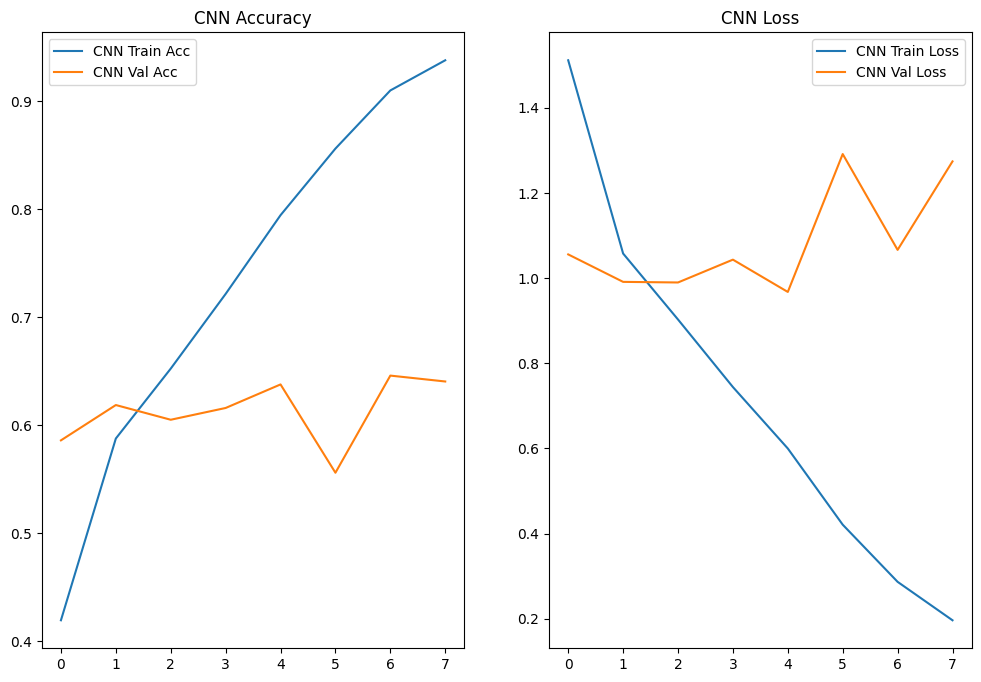
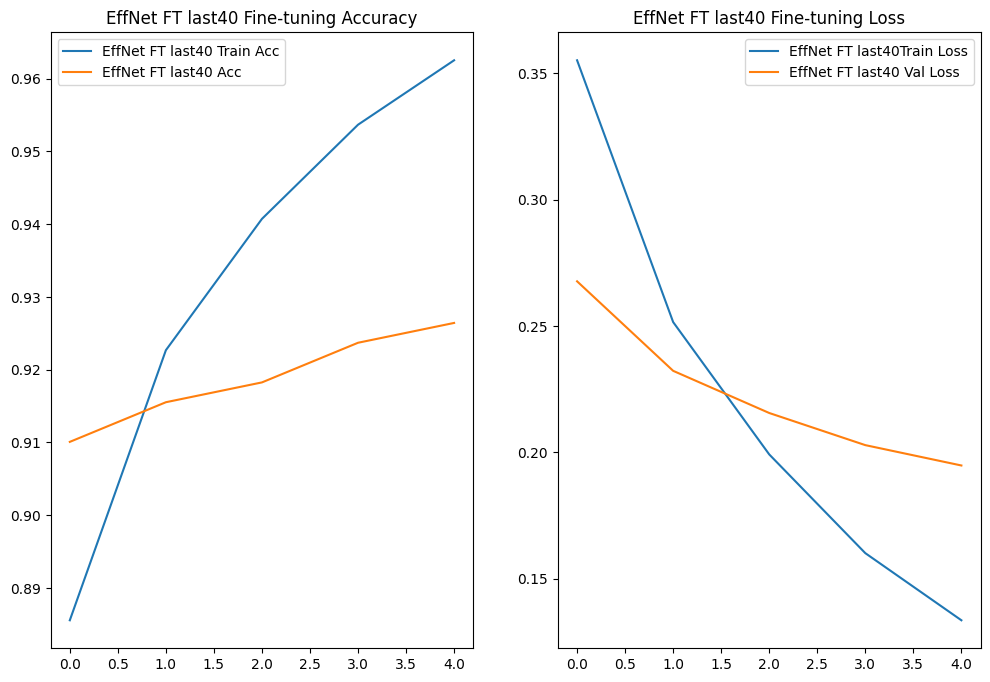
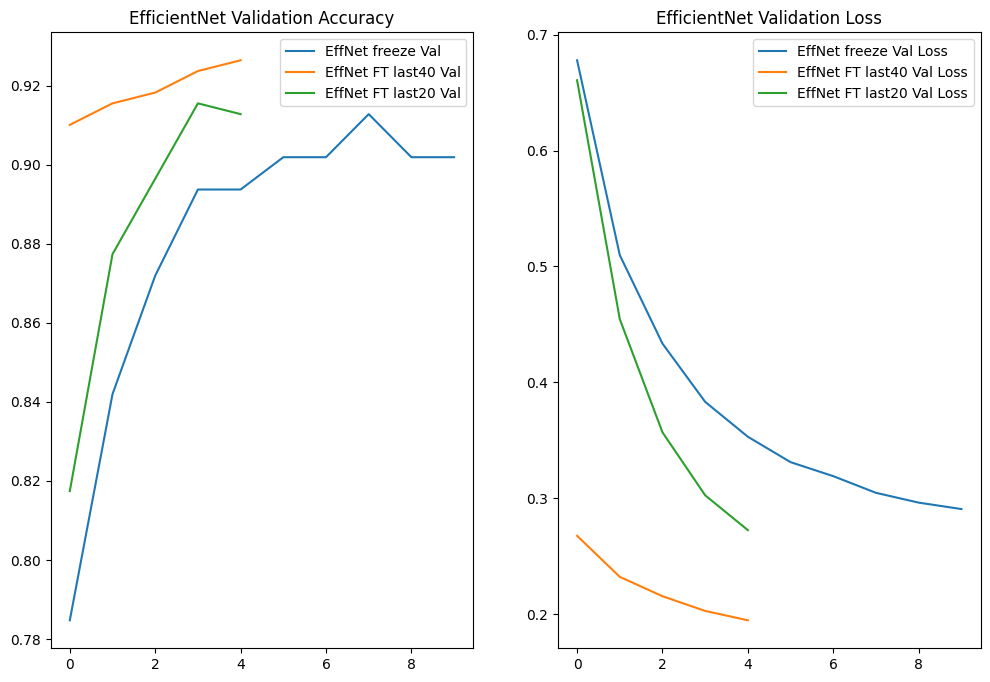


# 00_환경설정

In [1]:
import tensorflow as tf

AUTO = tf.data.AUTOTUNE

gpus = tf.config.list_physical_devices('GPU')
cpus = tf.config.list_physical_devices('CPU')
print("CPUs:", cpus)
print("GPUs:", gpus)
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

I0000 00:00:1773207254.896831   11434 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


CPUs: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
GPUs: []


W0000 00:00:1773207276.689568   11434 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [2]:
import sys
print(sys.executable)
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds
print("np", np.__version__)
print("plt OK", plt is not None)
print("tf", tf.__version__)
print("tfds", tfds.__version__)

/mnt/d/git/01_mdls_ds8_open/08_dl/260311_dl_minipjt/.venv/bin/python
np 2.4.3
plt OK True
tf 2.21.0
tfds 4.9.9


## 데이터로드
- `tensorflow_datasets` 에 포함된 `tf_flowers` 데이터
-  `tfds.load`를 활용하여 데이터셋을 다운
- https://www.tensorflow.org/datasets/catalog/tf_flowers

In [3]:
import tensorflow as tf
import tensorflow_datasets as tfds

data_dir = "/mnt/d/git/01_mdls_ds8_open/08_dl/260311_dl_minipjt/data/flower"

(raw_train, raw_val, raw_test), info = tfds.load(
    'tf_flowers',
    split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'],
    with_info=True,
    as_supervised=True,
    data_dir=data_dir,)

print("info:", info)
print("train:", raw_train)
print("val:", raw_val)
print("test:", raw_test)

get_label_name = info.features['label'].int2str


Dl Completed...: 100%|██████████| 1/1 [00:24<00:00, 24.86s/ url]
                                                                        

Dataset tf_flowers downloaded and prepared to /mnt/d/git/01_mdls_ds8_open/08_dl/260311_dl_minipjt/data/flower/tf_flowers/3.0.1. Subsequent calls will reuse this data.
info: tfds.core.DatasetInfo(
    name='tf_flowers',
    full_name='tf_flowers/3.0.1',
    description="""
    A large set of images of flowers
    """,
    homepage='https://www.tensorflow.org/tutorials/load_data/images',
    data_dir='/mnt/d/git/01_mdls_ds8_open/08_dl/260311_dl_minipjt/data/flower/tf_flowers/3.0.1',
    file_format=tfrecord,
    download_size=218.21 MiB,
    dataset_size=221.83 MiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=5),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'train': <SplitInfo num_examples=3670, num_shards=2>,
    },
    citation="""@ONLINE {tfflowers,
    author = "The TensorFlow Team",
    title

In [5]:
# 한 샘플 추출
for image, label in raw_train.take(1):
    print("image shape:", image.shape)
    print("image dtype:", image.dtype)
    print("label:", label, "dtype:", label.dtype)
    print("label name:", get_label_name(label))

image shape: (333, 500, 3)
image dtype: <dtype: 'uint8'>
label: tf.Tensor(2, shape=(), dtype=int64) dtype: <dtype: 'int64'>
label name: tulips


I0000 00:00:1773207362.767114   11899 tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608
W0000 00:00:1773207362.814426   11905 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


In [6]:
# 전체 구조(개수, 클래스 수) 확인
num_train = info.splits['train[:80%]'].num_examples
num_val   = info.splits['train[80%:90%]'].num_examples
num_test  = info.splits['train[90%:]'].num_examples
num_classes = info.features['label'].num_classes

print("num_train:", num_train)
print("num_val:", num_val)
print("num_test:", num_test)
print("num_classes:", num_classes)
print("class names:", info.features['label'].names)

num_train: 2936
num_val: 367
num_test: 367
num_classes: 5
class names: ['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']


# 01_데이터 전처리

- 이미지를 모두 같은 크기로 formatting
- train_batches, validation_batches, test_batches 준비

W0000 00:00:1773207568.478535   12600 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


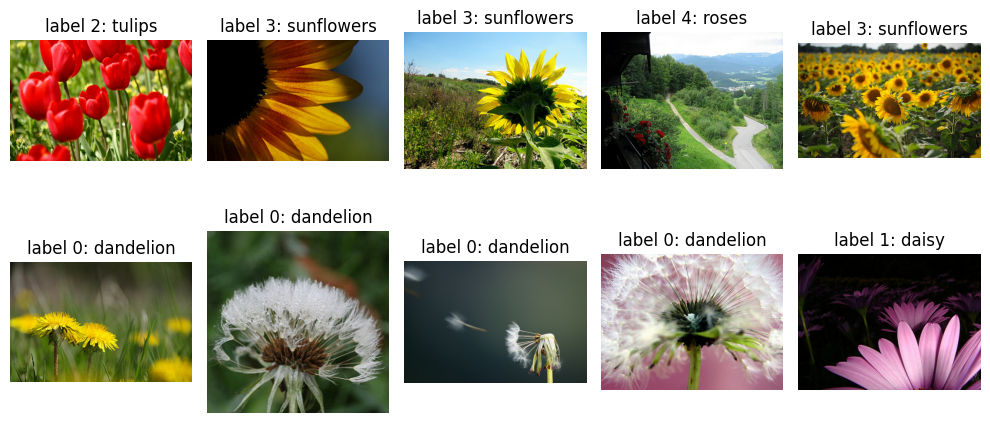

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

get_label_name = info.features['label'].int2str  # metadata → info

for idx, (image, label) in enumerate(raw_train.take(10)):
    plt.subplot(2, 5, idx + 1)
    plt.imshow(image)  # uint8 [0,255]
    plt.title(f'label {label.numpy()}: {get_label_name(label)}')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [11]:
IMG_SIZE = 160  # 리사이즈할 크기

def format_example(image, label):
    # 원본: uint8 [0, 255] → float32 [-1, 1]
    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = (image / 127.5) - 1.0
    return image, label

In [16]:
AUTO = tf.data.AUTOTUNE
BATCH_SIZE = 32
SHUFFLE_BUFFER_SIZE = 1000

train = raw_train.map(format_example, num_parallel_calls=AUTO)
val   = raw_val.map(format_example,   num_parallel_calls=AUTO)
test  = raw_test.map(format_example,  num_parallel_calls=AUTO)

train_batches = (train
                 .shuffle(SHUFFLE_BUFFER_SIZE)
                 .batch(BATCH_SIZE)
                 .prefetch(AUTO))

val_batches = (val
               .batch(BATCH_SIZE)
               .prefetch(AUTO))

test_batches = (test
                .batch(BATCH_SIZE)
                .prefetch(AUTO))

W0000 00:00:1773207650.828125   12934 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


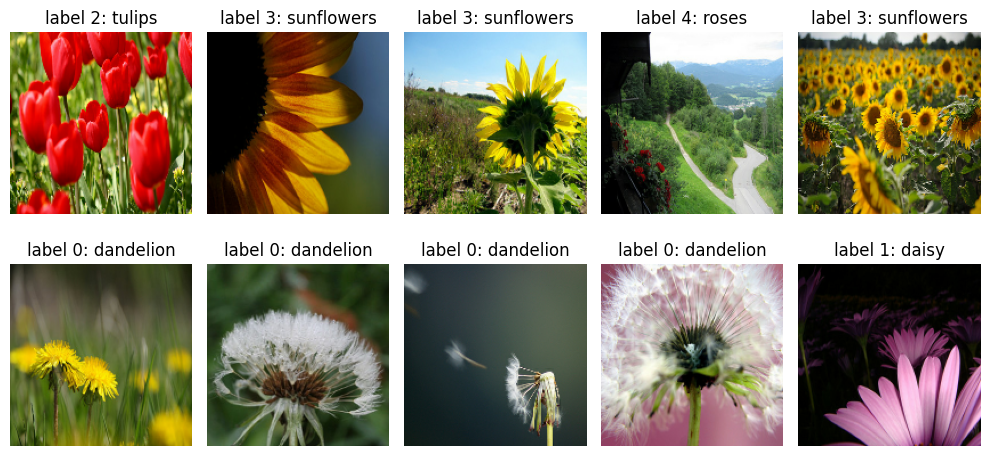

In [17]:
plt.figure(figsize=(10, 5))

get_label_name = info.features['label'].int2str

for idx, (image, label) in enumerate(train.take(10)):  # 전처리된 train
    plt.subplot(2, 5, idx + 1)
    image_to_show = (image + 1) / 2.0   # [-1,1] → [0,1]
    plt.imshow(image_to_show)
    plt.title(f'label {label.numpy()}: {get_label_name(label)}')
    plt.axis('off')

plt.tight_layout()
plt.show()

# 02_ 모델 설계
- cats_vs_dogs 의 경우와 달리, tf_flowers 데이터셋에서는 class 갯수가 5가지
- 차이사항 고려 필요

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, MaxPooling2D

# 모델 설계는 기존 LMS 내용 거의 그대로 차용 함

NUM_CLASSES = 5

model = Sequential([
    Conv2D(filters=16, kernel_size=3, padding='same',
           activation='relu', input_shape=(160, 160, 3)),
    MaxPooling2D(),
    Conv2D(filters=32, kernel_size=3, padding='same', activation='relu'),
    MaxPooling2D(),
    Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'),
    MaxPooling2D(),
    Flatten(),
    Dense(units=512, activation='relu'),
    Dense(units=NUM_CLASSES, activation='softmax'),  # 5개 클래스, 2 → 5 로 변경
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 160, 160, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 80, 80, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 40, 40, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    13,107,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,133,861 (50.10 MB)

 Trainable params: 13,133,861 (50.10 MB)

 Non-trainable params: 0 (0.00 B)

# 03_모델 컴파일 및 학습
- 여러 옵션으로 모델학습 
- epoch, optimizer, learning_rate, base model(VGG16 말고),Regularization  등


## Base line

In [ ]:
# 컴파일  
learning_rate = 0.001

model.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=learning_rate),
    loss=tf.keras.losses.sparse_categorical_crossentropy,
    metrics=['accuracy'],
)

In [20]:
# 학습
EPOCHS = 10
history = model.fit(
    train_batches,
    epochs=EPOCHS,
    validation_data=val_batches,
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 208ms/step - accuracy: 0.4506 - loss: 1.5041 - val_accuracy: 0.5341 - val_loss: 1.0927
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 213ms/step - accuracy: 0.6035 - loss: 1.0185 - val_accuracy: 0.6322 - val_loss: 0.9570
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 202ms/step - accuracy: 0.6877 - loss: 0.8140 - val_accuracy: 0.5940 - val_loss: 0.9810
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 226ms/step - accuracy: 0.7725 - loss: 0.6013 - val_accuracy: 0.6458 - val_loss: 0.9446
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 221ms/step - accuracy: 0.8658 - loss: 0.3802 - val_accuracy: 0.6649 - val_loss: 1.0609
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 203ms/step - accuracy: 0.9261 - loss: 0.2177 - val_accuracy: 0.6512 - val_loss: 1.2035
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 202ms/step - accuracy: 0.9625 - loss: 0.1272 - val_accuracy: 0.6676 - val_loss: 1.1608
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 203ms/step - accuracy: 0.9809 - loss: 0.0742 - val_accu

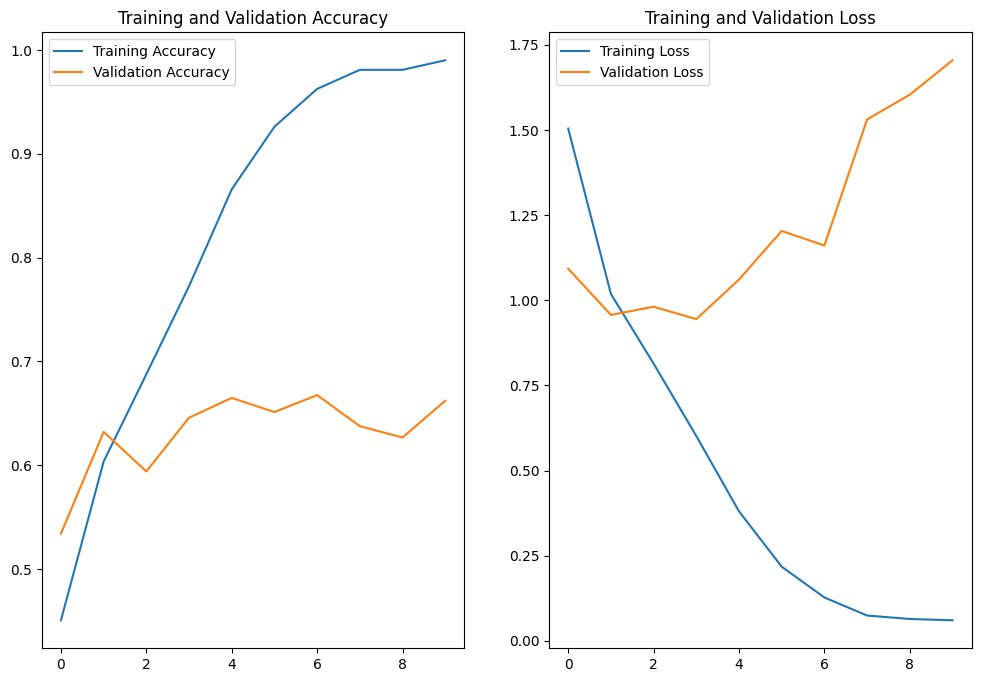

In [21]:
# 확인용 시각화 
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
# 모델 저장 
model.save("floawer_base.keras")
# 불러오기 
# from tensorflow import keras
# model = keras.models.load_model("floawer_base.keras")

## Ver_01_ Dropout + EarlyStopping + learning_rate

In [ ]:
# 과적합 해소를 위해 ropout + 규제 추가 
# learning_rate 좀더 세밀하게 
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping

NUM_CLASSES = 5

model = Sequential([
    Conv2D(16, 3, padding='same', activation='relu',
           input_shape=(160, 160, 3)),
    MaxPooling2D(),
    Conv2D(32, 3, padding='same', activation='relu'),
    MaxPooling2D(),
    Conv2D(64, 3, padding='same', activation='relu'),
    MaxPooling2D(),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),                        # Dropout 추가
    Dense(NUM_CLASSES, activation='softmax'),
])

learning_rate = 0.0007  # learning rate 도 일부 조정함

model.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=learning_rate),
    loss=tf.keras.losses.sparse_categorical_crossentropy,
    metrics=['accuracy'],
)

# EarlyStopping 3 epoch 안좋아지면 정지
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1,
)

EPOCHS = 15
history = model.fit(
    train_batches,
    epochs=EPOCHS,
    validation_data=val_batches,
    callbacks=[early_stop],
)


Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 195ms/step - accuracy: 0.4193 - loss: 1.5119 - val_accuracy: 0.5858 - val_loss: 1.0558
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 210ms/step - accuracy: 0.5875 - loss: 1.0579 - val_accuracy: 0.6185 - val_loss: 0.9913
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 216ms/step - accuracy: 0.6522 - loss: 0.9029 - val_accuracy: 0.6049 - val_loss: 0.9898
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 193ms/step - accuracy: 0.7214 - loss: 0.7442 - val_accuracy: 0.6158 - val_loss: 1.0435
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 200ms/step - accuracy: 0.7943 - loss: 0.5998 - val_accuracy: 0.6376 - val_loss: 0.9676
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 189ms/step - accuracy: 0.8559 - loss: 0.4208 - val_accuracy: 0.5559 - val_loss: 1.2916
Epoch 7/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 199ms/step - accuracy: 0.9097 - loss: 0.2865 - val_accuracy: 0.6458 - val_loss: 1.0664
Epoch 8/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 188ms/step - accuracy: 0.9377 - loss: 0.1962 - val_accu

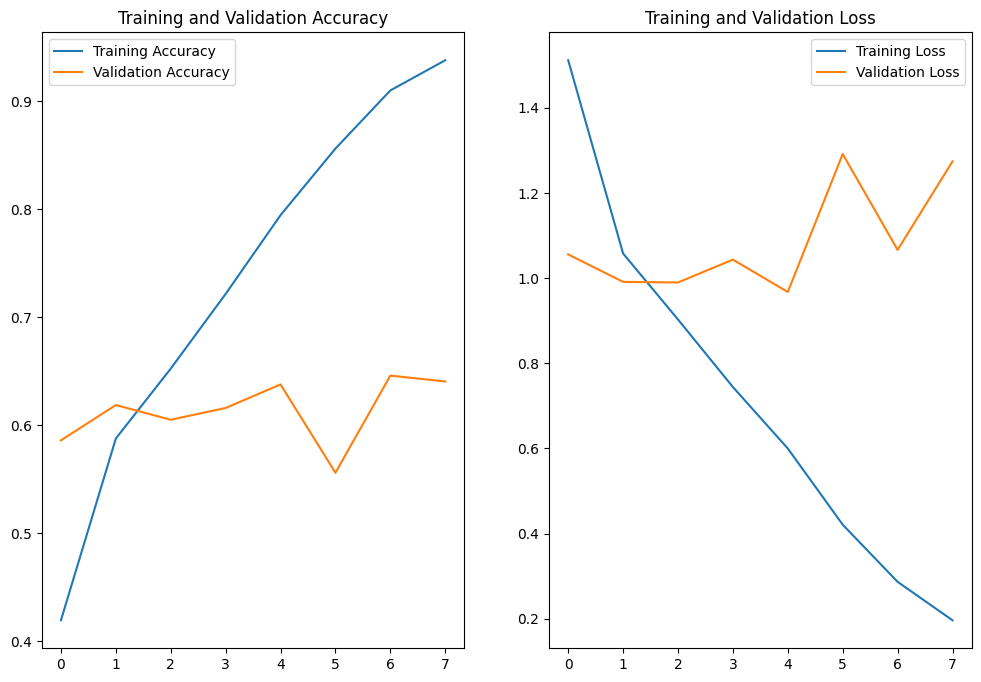

In [27]:
# 확인용 시각화 
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))  # EPOCHS 대신 len(acc)

plt.figure(figsize=(12, 8))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.show()

In [ ]:
# 모델 저장 
model.save("Ver_01.keras")
# 불러오기 
# from tensorflow import keras
# model = keras.models.load_model("Ver_01.keras")

## Ver_02_EfficientNet 전이학습
- 예전 의료영상 관련 개인 프로젝트 수행 시에 EfficientNet을 사용했던 기억이 있어 활용해 봤습니다

In [ ]:
from tensorflow.keras import layers, models, applications

IMG_SIZE = 224      # EfficientNet 전이학습용 입력 크기
NUM_CLASSES = 5

# 전처리 함수 새로 정의 + 파이프 라인 구성
def format_example_eff(image, label):
    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image / 255.0
    return image, label

train_eff = raw_train.map(format_example_eff, num_parallel_calls=AUTO)
val_eff   = raw_val.map(format_example_eff,   num_parallel_calls=AUTO)
test_eff  = raw_test.map(format_example_eff,  num_parallel_calls=AUTO)

train_eff_batches = (train_eff
                     .shuffle(SHUFFLE_BUFFER_SIZE)
                     .batch(BATCH_SIZE)
                     .prefetch(AUTO))
val_eff_batches = (val_eff
                   .batch(BATCH_SIZE)
                   .prefetch(AUTO))
test_eff_batches = (test_eff
                    .batch(BATCH_SIZE)
                    .prefetch(AUTO))

In [48]:
# EfficientNetV2B0
# 전이학습 최초 시도에서는
# EfficientNet 레이어 전체를 얼려서 그대로 사용 (뒷단 Dense레이어만 분류기 용도로 달기)
base_model = applications.EfficientNetV2B0(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_preprocessing=False,
)

base_model.trainable = False  # EfficientNet을 학습으로 사용하지는 않음 

# 뒷단 Dense레이어 한층만 추가
model_eff = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax'),
])

learning_rate_eff = 0.0005

model_eff.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate_eff),
    loss=tf.keras.losses.sparse_categorical_crossentropy,
    metrics=['accuracy'],
)

early_stop_eff = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1,
)

EPOCHS_EFF = 10
history_eff = model_eff.fit(
    train_eff_batches,
    epochs=EPOCHS_EFF,
    validation_data=val_eff_batches,
    callbacks=[early_stop_eff],
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 44s 396ms/step - accuracy: 0.6052 - loss: 1.0607 - val_accuracy: 0.7847 - val_loss: 0.6779
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 37s 405ms/step - accuracy: 0.7936 - loss: 0.6271 - val_accuracy: 0.8420 - val_loss: 0.5098
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 40s 431ms/step - accuracy: 0.8311 - loss: 0.5097 - val_accuracy: 0.8719 - val_loss: 0.4335
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 32s 350ms/step - accuracy: 0.8529 - loss: 0.4507 - val_accuracy: 0.8937 - val_loss: 0.3832
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 38s 409ms/step - accuracy: 0.8685 - loss: 0.4070 - val_accuracy: 0.8937 - val_loss: 0.3531
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 35s 376ms/step - accuracy: 0.8767 - loss: 0.3794 - val_accuracy: 0.9019 - val_loss: 0.3312
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 36s 386ms/step - accuracy: 0.8791 - loss: 0.3555 - val_accuracy: 0.9019 - val_loss: 0.3191
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 35s 382ms/step - accuracy: 0.8873 - loss: 0.3390 - val_accu

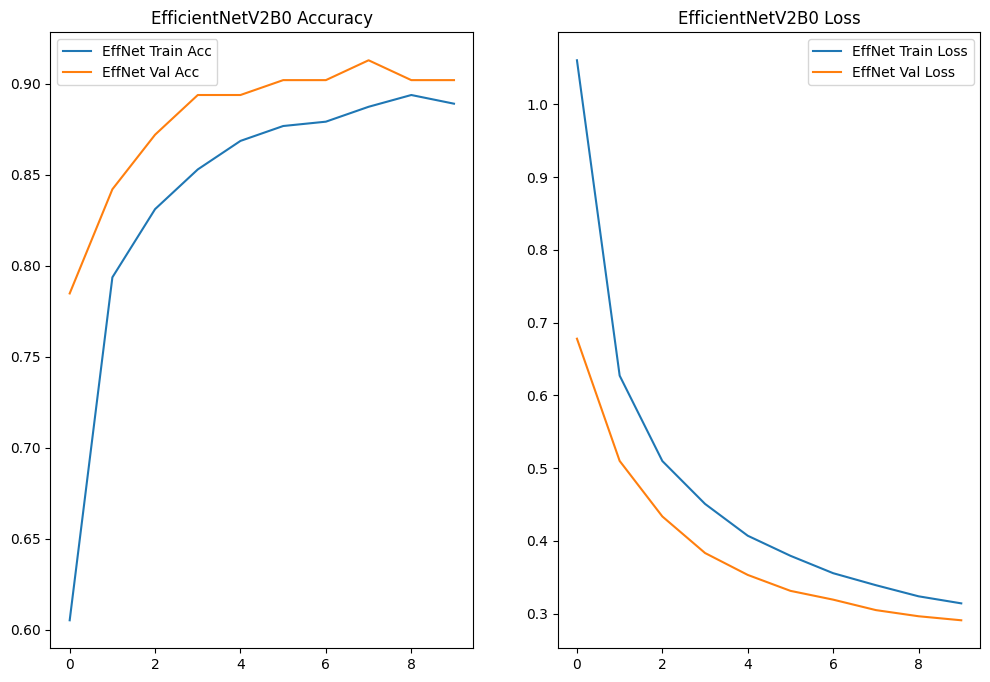

In [49]:
# EfficientNet 시각화
acc_eff = history_eff.history['accuracy']
val_acc_eff = history_eff.history['val_accuracy']
loss_eff = history_eff.history['loss']
val_loss_eff = history_eff.history['val_loss']
epochs_range_eff = range(len(acc_eff))

plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range_eff, acc_eff, label='EffNet Train Acc')
plt.plot(epochs_range_eff, val_acc_eff, label='EffNet Val Acc')
plt.legend()
plt.title('EfficientNetV2B0 Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range_eff, loss_eff, label='EffNet Train Loss')
plt.plot(epochs_range_eff, val_loss_eff, label='EffNet Val Loss')
plt.legend()
plt.title('EfficientNetV2B0 Loss')

plt.show()

In [ ]:
# CNN 성능 
test_loss_cnn, test_acc_cnn = model.evaluate(test_batches)
print("CNN test acc:", test_acc_cnn)

# EfficientNet 성능 
test_loss_eff, test_acc_eff = model_eff.evaluate(test_eff_batches)
print("EfficientNetV2B0 test acc:", test_acc_eff)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.6131 - loss: 0.9842
CNN test acc: 0.6130790114402771
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 267ms/step - accuracy: 0.9019 - loss: 0.2902
EfficientNetV2B0 test acc: 0.9019073843955994


In [ ]:
# 모델 저장 
model.save("floawer_eff.keras")

# 불러오기 
# from tensorflow import keras
# model = keras.models.load_model("floawer_eff.keras")

## Ver_03_EfficientNet 전이학습 파인튜닝

In [ ]:
# 전이학습 파인튜닝 에서는 
# EfficientNet 레이어 중에서 뒷쪽 추상화를 담당하는 레이서 40개를 학습에 사용 

base_model.trainable = True # EfficientNet 모든 레이어로 학습고려 

# 그중에서 앞쪽 레이어 들은 빼고
# 맨 뒤 40개를 학습에 이용함 
fine_tune_at = len(base_model.layers) - 40   

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# 학습 레이어 설정 확인 
print("전체 레이어 수:", len(base_model.layers))
print("사용 레이어 수:",
      sum([l.trainable for l in base_model.layers]))


Total layers: 268
Trainable layers: 40


In [ ]:
fine_tune_lr = 1e-4 # learning rate 아주 작게 설정

model_eff.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=fine_tune_lr),
    loss=tf.keras.losses.sparse_categorical_crossentropy,
    metrics=['accuracy'],
)

#  파인튜닝 학습
FINE_TUNE_EPOCHS = 5 

history_eff_fine = model_eff.fit(
    train_eff_batches,
    epochs=FINE_TUNE_EPOCHS,
    validation_data=val_eff_batches,
    callbacks=[early_stop_eff],
)

Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 55s 489ms/step - accuracy: 0.8856 - loss: 0.3551 - val_accuracy: 0.9101 - val_loss: 0.2677
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 45s 485ms/step - accuracy: 0.9227 - loss: 0.2515 - val_accuracy: 0.9155 - val_loss: 0.2322
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 46s 499ms/step - accuracy: 0.9407 - loss: 0.1992 - val_accuracy: 0.9183 - val_loss: 0.2156
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 45s 473ms/step - accuracy: 0.9537 - loss: 0.1601 - val_accuracy: 0.9237 - val_loss: 0.2028
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 46s 495ms/step - accuracy: 0.9625 - loss: 0.1335 - val_accuracy: 0.9264 - val_loss: 0.1948
Restoring model weights from the end of the best epoch: 5.


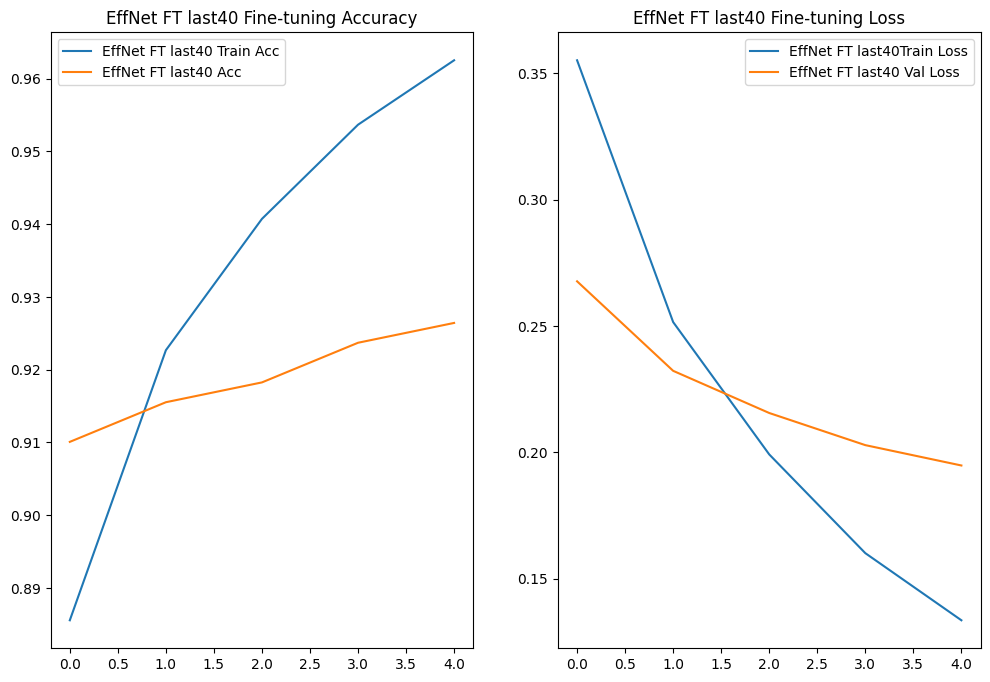

In [57]:
# EfficientNet 파인튜닝 시각화
acc_eff_ft = history_eff_fine.history['accuracy']
val_acc_eff_ft = history_eff_fine.history['val_accuracy']
loss_eff_ft = history_eff_fine.history['loss']
val_loss_eff_ft = history_eff_fine.history['val_loss']
epochs_range_eff_ft = range(len(acc_eff_ft))

plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range_eff_ft, acc_eff_ft, label='EffNet FT last40 Train Acc')
plt.plot(epochs_range_eff_ft, val_acc_eff_ft, label='EffNet FT last40 Acc')
plt.legend()
plt.title('EffNet FT last40 Fine-tuning Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range_eff_ft, loss_eff_ft, label='EffNet FT last40Train Loss')
plt.plot(epochs_range_eff_ft, val_loss_eff_ft, label='EffNet FT last40 Val Loss')
plt.legend()
plt.title('EffNet FT last40 Fine-tuning Loss')

plt.show()

In [37]:
# 파인튜닝 후 test 성능
test_loss_eff_ft, test_acc_eff_ft = model_eff.evaluate(test_eff_batches)
print("EfficientNetV2B0 fine-tuned test acc:", test_acc_eff_ft)

12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 387ms/step - accuracy: 0.9373 - loss: 0.1766
EfficientNetV2B0 fine-tuned test acc: 0.9373297095298767


In [40]:
# 모델 저장 
model.save("floawer_eff_fin.keras")

# 불러오기 
# from tensorflow import keras
# model = keras.models.load_model("floawer_eff_fin.kerass")
# preds = model.predict(test_batches) # 예측
# # 이어서 학습
# model.fit(
#     train_batches,
#     epochs=5,                    # 추가로 돌릴 횟수
#     validation_data=validation_batches,
# )

## Ver_03_EfficientNet 전이학습 파인튜닝_2차

In [ ]:
# 2차 전이학습에서는 학습에 사용하는 EfficientNet 레이어를 줄여서 (40 -> 20)
# 과적합 가능성을 방지하려 했음 

from tensorflow.keras import layers, models, applications

base_model_20 = applications.EfficientNetV2B0(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_preprocessing=False,
)
base_model_20.trainable = True

fine_tune_at_20 = len(base_model_20.layers) - 20 # 맨 뒤 20개 레이어로 학습

for layer in base_model_20.layers[:fine_tune_at_20]:
    layer.trainable = False

In [45]:
inputs_20 = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x_20 = base_model_20(inputs_20, training=True)
x_20 = layers.GlobalAveragePooling2D()(x_20)
x_20 = layers.Dropout(0.3)(x_20)
outputs_20 = layers.Dense(NUM_CLASSES, activation='softmax')(x_20)

model_eff_ft20 = tf.keras.Model(inputs_20, outputs_20,
                                name="effnetv2b0_ft_last20")

In [46]:
model_eff_ft20.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.sparse_categorical_crossentropy,
    metrics=['accuracy'],
)

early_stop_eff20 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True,
    verbose=1,
)

FINE_TUNE_EPOCHS_20 = 5 

history_eff_ft20 = model_eff_ft20.fit(
    train_eff_batches,
    epochs=FINE_TUNE_EPOCHS_20,
    validation_data=val_eff_batches,
    callbacks=[early_stop_eff20],
)

Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 52s 470ms/step - accuracy: 0.6110 - loss: 1.1269 - val_accuracy: 0.8174 - val_loss: 0.6607
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 45s 492ms/step - accuracy: 0.8140 - loss: 0.6167 - val_accuracy: 0.8774 - val_loss: 0.4546
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 42s 459ms/step - accuracy: 0.8590 - loss: 0.4635 - val_accuracy: 0.8965 - val_loss: 0.3569
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 41s 445ms/step - accuracy: 0.8774 - loss: 0.3894 - val_accuracy: 0.9155 - val_loss: 0.3026
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 40s 428ms/step - accuracy: 0.8924 - loss: 0.3392 - val_accuracy: 0.9128 - val_loss: 0.2725
Restoring model weights from the end of the best epoch: 5.


In [ ]:
# 성능 비교만 -> 과적합 끼가 보여서 레이어 수 줄여 봤는데 성능 저하됨 
test_loss_eff_ft20, test_acc_eff_ft20 = model_eff_ft20.evaluate(test_eff_batches)
print("EffNet FT (last 40 layers) test acc  ~", test_acc_eff_ft)
print("EffNet FT (last 20 layers) test acc  ~", test_acc_eff_ft20)

12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 307ms/step - accuracy: 0.9046 - loss: 0.2906
EffNet FT (last 40 layers) test acc  ~ 0.9373297095298767
EffNet FT (last 20 layers) test acc  ~ 0.9046321511268616


# 04_모델 성능 평가
- 모델 학습 과정 그래프
- validation_batches나 test_batches에 있는 데이터에 대한 예측 결과도 확인

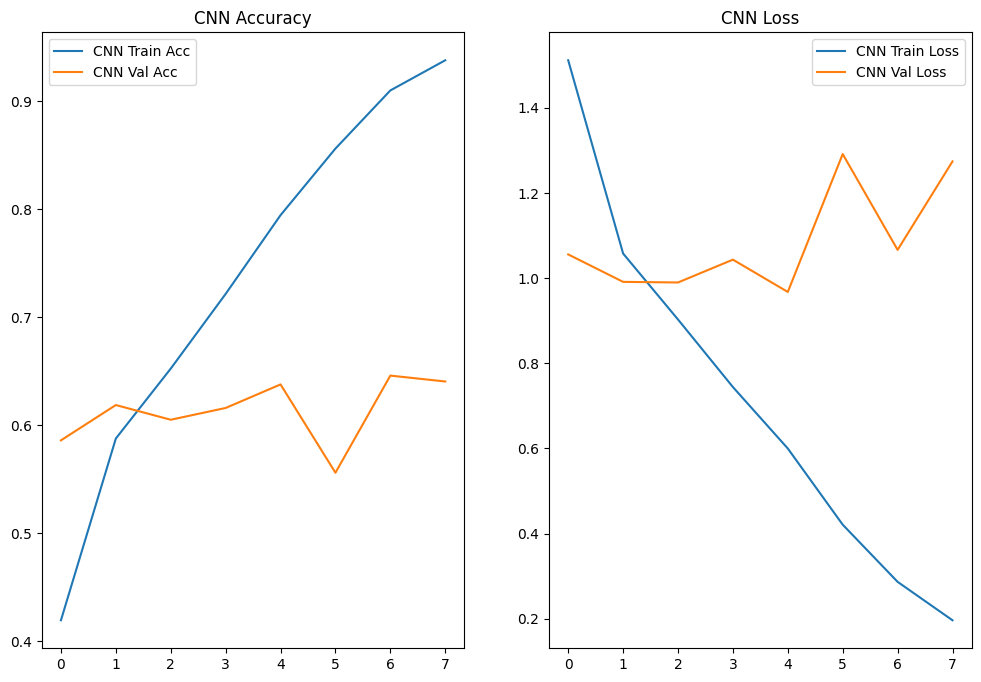

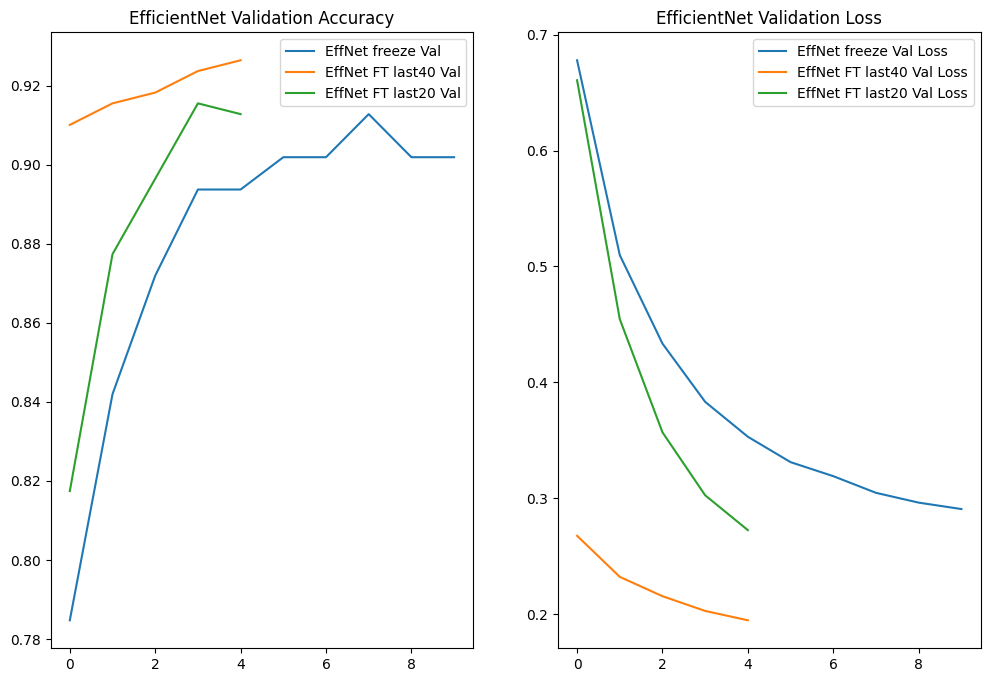

In [ ]:
# 모델별 시각화 
# CNN (Ver_01) 학습 곡선
acc_cnn = history.history['accuracy']
val_acc_cnn = history.history['val_accuracy']
loss_cnn = history.history['loss']
val_loss_cnn = history.history['val_loss']
epochs_cnn = range(len(acc_cnn))

plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_cnn, acc_cnn, label='CNN Train Acc')
plt.plot(epochs_cnn, val_acc_cnn, label='CNN Val Acc')
plt.legend()
plt.title('CNN Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_cnn, loss_cnn, label='CNN Train Loss')
plt.plot(epochs_cnn, val_loss_cnn, label='CNN Val Loss')
plt.legend()
plt.title('CNN Loss')
plt.show()

# EfficientNet freeze / fine-tuning / last20 비교
# 현재 실험에서는 레이어를 많이 학습에 이용한 모델이 성능이 좋음
acc_eff = history_eff.history['accuracy']
val_acc_eff = history_eff.history['val_accuracy']
loss_eff = history_eff.history['loss']
val_loss_eff = history_eff.history['val_loss']
epochs_eff = range(len(acc_eff))

acc_eff_ft = history_eff_fine.history['accuracy']
val_acc_eff_ft = history_eff_fine.history['val_accuracy']
loss_eff_ft = history_eff_fine.history['loss']
val_loss_eff_ft = history_eff_fine.history['val_loss']
epochs_eff_ft = range(len(acc_eff_ft))

acc_eff_ft20 = history_eff_ft20.history['accuracy']
val_acc_eff_ft20 = history_eff_ft20.history['val_accuracy']
loss_eff_ft20 = history_eff_ft20.history['loss']
val_loss_eff_ft20 = history_eff_ft20.history['val_loss']
epochs_eff_ft20 = range(len(acc_eff_ft20))

plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_eff,     val_acc_eff,     label='EffNet freeze Val')
plt.plot(epochs_eff_ft,  val_acc_eff_ft,  label='EffNet FT last40 Val')
plt.plot(epochs_eff_ft20,val_acc_eff_ft20,label='EffNet FT last20 Val')
plt.legend()
plt.title('EfficientNet Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_eff,     val_loss_eff,     label='EffNet freeze Val Loss')
plt.plot(epochs_eff_ft,  val_loss_eff_ft,  label='EffNet FT last40 Val Loss')
plt.plot(epochs_eff_ft20,val_loss_eff_ft20,label='EffNet FT last20 Val Loss')
plt.legend()
plt.title('EfficientNet Validation Loss')
plt.show()

In [56]:
# 모델별 요약 표
import pandas as pd

results = pd.DataFrame([
    ["CNN baseline (Ver_01)",        "~0.66", f"{test_acc_cnn:.3f}"],
    ["EffNet freeze (Ver_02)",       "~0.91", f"{test_acc_eff:.3f}"],
    ["EffNet FT last 40 (Ver_03)",   "~0.93", f"{test_acc_eff_ft:.3f}"],
    ["EffNet FT last 20 (Ver_03_2)", "~0.91", f"{test_acc_eff_ft20:.3f}"],
], columns=["Model", "Val acc (approx)", "Test acc"])

display(results)

,Model,Val acc (approx),Test acc
0,CNN baseline (Ver_01),~0.66,0.613
1,EffNet freeze (Ver_02),~0.91,0.902
2,EffNet FT last 40 (Ver_03),~0.93,0.937
3,EffNet FT last 20 (Ver_03_2),~0.91,0.905
